In [146]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.feature_selection import RFE
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

In [6]:
data = pd.read_csv("D:/Thesis/Model Apply 2018/archive/02-21-2018.csv")
data.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,6,21/02/2018 08:33:25,37953,5,3,135,127,135,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,500,17,21/02/2018 08:33:06,117573474,3,0,1500,0,500,500,...,8,0.0,0.0,0,0,58800000.0,23800000.0,75600000,42000000,Benign
2,500,17,21/02/2018 08:33:06,117573474,3,0,1500,0,500,500,...,8,0.0,0.0,0,0,58800000.0,23800000.0,75600000,42000000,Benign
3,500,17,21/02/2018 08:33:11,99743998,5,0,2500,0,500,500,...,8,4000290.0,0.0,4000290,4000290,31900000.0,37900000.0,75600000,7200397,Benign
4,500,17,21/02/2018 08:33:11,99743999,5,0,2500,0,500,500,...,8,4000286.0,0.0,4000286,4000286,31900000.0,37900000.0,75600000,7200399,Benign


In [7]:
data.drop(columns='Timestamp', inplace=True)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 79 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Flow Duration      1048575 non-null  int64  
 3   Tot Fwd Pkts       1048575 non-null  int64  
 4   Tot Bwd Pkts       1048575 non-null  int64  
 5   TotLen Fwd Pkts    1048575 non-null  int64  
 6   TotLen Bwd Pkts    1048575 non-null  int64  
 7   Fwd Pkt Len Max    1048575 non-null  int64  
 8   Fwd Pkt Len Min    1048575 non-null  int64  
 9   Fwd Pkt Len Mean   1048575 non-null  float64
 10  Fwd Pkt Len Std    1048575 non-null  float64
 11  Bwd Pkt Len Max    1048575 non-null  int64  
 12  Bwd Pkt Len Min    1048575 non-null  int64  
 13  Bwd Pkt Len Mean   1048575 non-null  float64
 14  Bwd Pkt Len Std    1048575 non-null  float64
 15  Flow Byts/s        1048575 non-n

In [9]:
# Write the selected column.
selected_columns = ['Dst Port','Tot Bwd Pkts','Fwd Pkt Len Std','Bwd Pkt Len Std','Fwd Seg Size Avg','Init Bwd Win Byts','Bwd IAT Mean','PSH Flag Cnt','Bwd Pkt Len Max','Init Fwd Win Byts','Subflow Bwd Pkts','Bwd Seg Size Avg','Bwd Pkt Len Mean','Label']

In [10]:
# Only take the selected column from the dataset.
data = data[selected_columns]
data.head()

,Dst Port,Tot Bwd Pkts,Fwd Pkt Len Std,Bwd Pkt Len Std,Fwd Seg Size Avg,Init Bwd Win Byts,Bwd IAT Mean,PSH Flag Cnt,Bwd Pkt Len Max,Init Fwd Win Byts,Subflow Bwd Pkts,Bwd Seg Size Avg,Bwd Pkt Len Mean,Label
0,80,3,60.373835,73.323484,27.0,219,9980.0,1,127,29200,3,42.333333,42.333333,Benign
1,500,0,0.000000,0.000000,500.0,-1,0.0,0,0,-1,0,0.000000,0.000000,Benign
2,500,0,0.000000,0.000000,500.0,-1,0.0,0,0,-1,0,0.000000,0.000000,Benign
3,500,0,0.000000,0.000000,500.0,-1,0.0,0,0,-1,0,0.000000,0.000000,Benign
4,500,0,0.000000,0.000000,500.0,-1,0.0,0,0,-1,0,0.000000,0.000000,Benign


In [11]:
# replace +ve and -ve infinity with NaN
data.replace([np.inf, -np.inf], np.nan, inplace=True)

In [12]:
data.describe()

,Dst Port,Tot Bwd Pkts,Fwd Pkt Len Std,Bwd Pkt Len Std,Fwd Seg Size Avg,Init Bwd Win Byts,Bwd IAT Mean,PSH Flag Cnt,Bwd Pkt Len Max,Init Fwd Win Byts,Subflow Bwd Pkts,Bwd Seg Size Avg,Bwd Pkt Len Mean
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.958764e+04,1.309663e+00,1.699519e+02,1.455142e+02,7.977144e+01,1.123803e+04,2.822531e+03,4.983296e-01,2.485879e+02,4.895170e+04,1.309663e+00,8.777145e+01,8.777145e+01
std,2.719338e+04,1.477423e+00,1.887000e+02,1.687515e+02,8.511139e+01,1.551953e+04,3.604474e+04,4.999974e-01,3.252947e+02,1.663954e+04,1.477423e+00,9.267301e+01,9.267301e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.273800e+04,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.273800e+04,0.000000e+00,0.000000e+00,0.000000e+00
75%,5.355300e+04,2.000000e+00,4.181447e+02,2.234457e+02,1.870000e+02,3.276800e+04,1.687667e+03,1.000000e+00,3.160000e+02,6.553500e+04,2.000000e+00,1.580000e+02,1.580000e+02
max,6.553400e+04,1.240000e+02,6.901362e+02,4.993862e+02,9.760000e+02,3.276800e+04,1.910000e+07,1.000000e+00,1.104000e+03,6.553500e+04,1.240000e+02,1.104000e+03,1.104000e+03


In [13]:
# drop missing values
data.dropna(inplace=True)

In [14]:
# To see how many record fall in each classes.
data['Label'].value_counts()

Label
DDOS attack-HOIC        686012
Benign                  360833
DDOS attack-LOIC-UDP      1730
Name: count, dtype: int64

In [15]:
from plotly.offline import init_notebook_mode, iplot, plot
import plotly as py
import plotly.express as px
init_notebook_mode(connected=True)
import plotly.graph_objs as go

fig = go.Figure(data=[
    go.Bar(name='Benign', 
           y=data["Label"].value_counts().values[1:2],
           x=['Benign'],
           text = data["Label"].value_counts()[1:2],
           orientation='v',
           textposition='outside',),
    go.Bar(name='DDOS attack-HOIC', 
           y=data["Label"].value_counts().values[0:1],
           x=['DDOS attack-HOIC'],
           text = data["Label"].value_counts()[0:1],
           orientation='v',
           textposition='outside',),
    go.Bar(name='DDOS attack-LOIC-UDP', 
           y=data["Label"].value_counts().values[2:],
           x=['DDOS attack-LOIC-UDP'],
           text = data["Label"].value_counts()[2:],
           orientation='v',
           textposition='outside',)
])
# Change the bar mode
fig.update_layout(
                  width=800,
                  height=600,
                  title=f'Class Distribution',
                  yaxis_title='Number of attacks',
                  xaxis_title='Attack Name',)
iplot(fig)

In [16]:
data.replace(to_replace=["DDOS attack-HOIC", "DDOS attack-LOIC-UDP"], value="Malicious", inplace=True)

In [17]:
data["Label"].value_counts()

Label
Malicious    687742
Benign       360833
Name: count, dtype: int64

In [18]:
fig = go.Figure(data=[
    go.Bar(name='Benign', 
           y=data["Label"].value_counts().values[1:2],
           x=['Benign'],
           text = data["Label"].value_counts()[1:2],
           orientation='v',
           textposition='outside',),
    go.Bar(name='Malicious', 
           y=data["Label"].value_counts().values[0:1],
           x=['Malicious'],
           text = data["Label"].value_counts()[0:1],
           orientation='v',
           textposition='outside',)
])
# Change the bar mode
fig.update_layout(
                  width=800,
                  height=600,
                  title=f'Class Distribution',
                  yaxis_title='Number of attacks',
                  xaxis_title='Attack Name',)
iplot(fig)

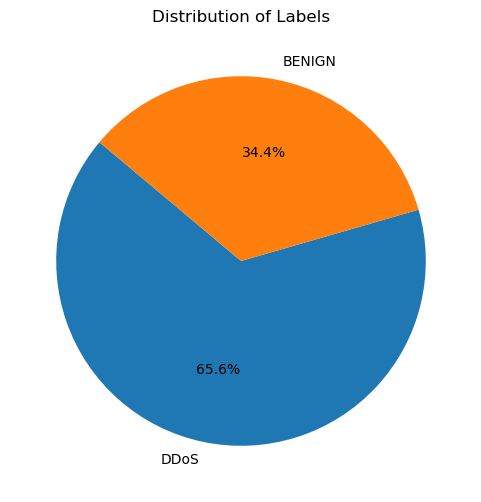

In [19]:
import matplotlib.pyplot as plt
# Assuming data is a pandas DataFrame
data1 = {'Label': ['DDoS', 'BENIGN'],
        'Count': [687742, 360833]}

# Plotting the pie chart
plt.figure(figsize=(6, 6))
plt.pie(data1['Count'], labels=data1['Label'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Labels')
plt.show()

In [20]:
x = data.iloc[:,:-1]
y = data['Label']

In [21]:
from collections import Counter
from imblearn.under_sampling import NearMiss

In [22]:
undersampling = NearMiss()

In [23]:
x_us,y_us = undersampling.fit_resample(x,y)

In [24]:
print("Orginal Dataset Shape: %s" %Counter(y))
print("After apply smote now dataset shape %s" %Counter(y_us))

Orginal Dataset Shape: Counter({'Malicious': 687742, 'Benign': 360833})
After apply smote now dataset shape Counter({'Benign': 360833, 'Malicious': 360833})


In [26]:
x_us.shape,y_us.shape

((721666, 13), (721666,))

In [27]:
# Apply the train test split.
x_train,x_test,y_train,y_test = train_test_split(x_us,y_us,test_size=0.2,stratify=y_us, random_state=42)

# Show Data After Balancing

In [153]:
labels, counts = np.unique(y_us, return_counts=True)

# Create the figure
fig = go.Figure()

# Add bars for each class
for label, count in zip(labels, counts):
    fig.add_trace(go.Bar(
        name=label,
        x=[label],
        y=[count],
        text=[count],
        textposition='outside',
        orientation='v'
    ))

# Update layout
fig.update_layout(
    width=800,
    height=600,
    title='Class Distribution after Undersampling',
    yaxis_title='Number of instances',
    xaxis_title='Class'
)

# Show the plot
iplot(fig)

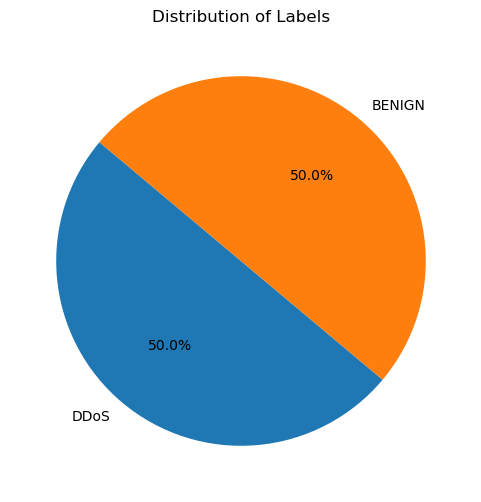

In [154]:
# Assuming data is a pandas DataFrame
data1 = {'Label': ['DDoS', 'BENIGN'],
        'Count': [360833, 360833]}

# Plotting the pie chart
plt.figure(figsize=(6, 6))
plt.pie(data1['Count'], labels=data1['Label'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Labels')
plt.show()

# Data Transformation

In [31]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [32]:
# Apply the label encoding to the target cloumn.
le = LabelEncoder()
y_train = le.fit_transform(np.ravel(y_train))
y_test = le.fit_transform(np.ravel(y_test))

In [130]:
x = scaler.fit_transform(x_us)
y = le.fit_transform(y_us)

# Apply Model

# Gradient Boosting.

In [29]:
ProcessGradientBoosting = GradientBoostingClassifier()

In [42]:
ProcessGradientBoosting.fit(x_train,y_train)

GradientBoostingClassifier()

In [64]:
yPredictGradientBoosting = ProcessGradientBoosting.predict(x_test)

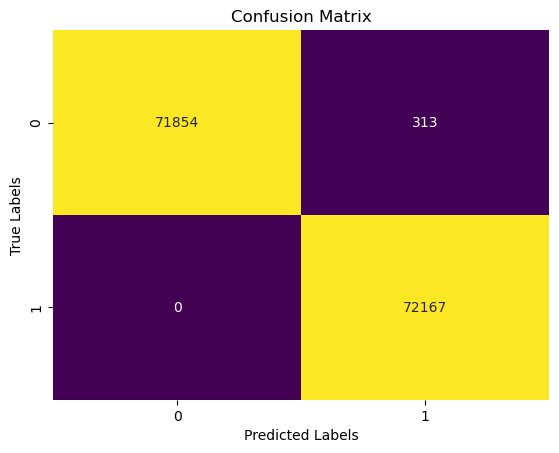

In [65]:
confMat = confusion_matrix(y_test,yPredictGradientBoosting)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [66]:
print(format(classification_report(y_test,yPredictGradientBoosting)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72167
           1       1.00      1.00      1.00     72167

    accuracy                           1.00    144334
   macro avg       1.00      1.00      1.00    144334
weighted avg       1.00      1.00      1.00    144334



In [67]:
print("f1 Score {}".format(f1_score(y_test,yPredictGradientBoosting)))
print("Recall Score {}".format(recall_score(y_test,yPredictGradientBoosting)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredictGradientBoosting)))
print("Precision Score {}".format(precision_score(y_test,yPredictGradientBoosting)))

f1 Score 0.997836111360761
Recall Score 1.0
Accuracy Score 0.9978314187925229
Precision Score 0.9956815673289183


### Random Forest

In [50]:
ProcessRandomForest = RandomForestClassifier()

In [52]:
ProcessRandomForest.fit(x_train,y_train)

RandomForestClassifier()

In [59]:
yPredictRandomForest = ProcessRandomForest.predict(x_test)

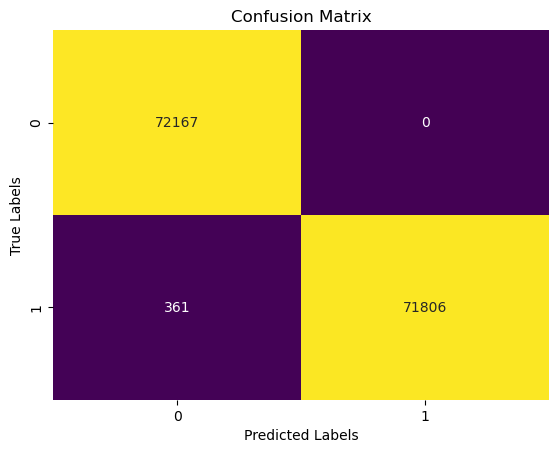

In [60]:
confMat = confusion_matrix(y_test,yPredictRandomForest)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [61]:
print(format(classification_report(y_test,yPredictRandomForest)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72167
           1       1.00      0.99      1.00     72167

    accuracy                           1.00    144334
   macro avg       1.00      1.00      1.00    144334
weighted avg       1.00      1.00      1.00    144334



In [62]:
print("f1 Score {}".format(f1_score(y_test,yPredictRandomForest)))
print("Recall Score {}".format(recall_score(y_test,yPredictRandomForest)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredictRandomForest)))
print("Precision Score {}".format(precision_score(y_test,yPredictRandomForest)))

f1 Score 0.9974925854153209
Recall Score 0.9949977136364266
Accuracy Score 0.9974988568182133
Precision Score 1.0


### CatBoosting

In [68]:
ProcessCatBoosting = CatBoostClassifier()

In [70]:
ProcessCatBoosting.fit(x_train,y_train)

Learning rate set to 0.155619
0:	learn: 0.2142465	total: 241ms	remaining: 4m
1:	learn: 0.0634018	total: 315ms	remaining: 2m 37s
2:	learn: 0.0243585	total: 392ms	remaining: 2m 10s
3:	learn: 0.0118096	total: 465ms	remaining: 1m 55s
4:	learn: 0.0069712	total: 534ms	remaining: 1m 46s
5:	learn: 0.0048195	total: 624ms	remaining: 1m 43s
6:	learn: 0.0043233	total: 702ms	remaining: 1m 39s
7:	learn: 0.0037772	total: 775ms	remaining: 1m 36s
8:	learn: 0.0036181	total: 836ms	remaining: 1m 32s
9:	learn: 0.0035220	total: 895ms	remaining: 1m 28s
10:	learn: 0.0034006	total: 975ms	remaining: 1m 27s
11:	learn: 0.0033778	total: 1.04s	remaining: 1m 26s
12:	learn: 0.0033648	total: 1.11s	remaining: 1m 24s
13:	learn: 0.0033531	total: 1.18s	remaining: 1m 22s
14:	learn: 0.0033506	total: 1.25s	remaining: 1m 21s
15:	learn: 0.0033506	total: 1.29s	remaining: 1m 19s
16:	learn: 0.0033108	total: 1.35s	remaining: 1m 18s
17:	learn: 0.0032964	total: 1.42s	remaining: 1m 17s
18:	learn: 0.0032732	total: 1.49s	remaining: 1m 

161:	learn: 0.0032518	total: 10.3s	remaining: 53.1s
162:	learn: 0.0032518	total: 10.3s	remaining: 53.1s
163:	learn: 0.0032518	total: 10.4s	remaining: 53.1s
164:	learn: 0.0032518	total: 10.5s	remaining: 53s
165:	learn: 0.0032518	total: 10.5s	remaining: 52.9s
166:	learn: 0.0032518	total: 10.6s	remaining: 52.8s
167:	learn: 0.0032518	total: 10.6s	remaining: 52.7s
168:	learn: 0.0032518	total: 10.7s	remaining: 52.6s
169:	learn: 0.0032518	total: 10.8s	remaining: 52.6s
170:	learn: 0.0032518	total: 10.8s	remaining: 52.5s
171:	learn: 0.0032518	total: 10.9s	remaining: 52.4s
172:	learn: 0.0032518	total: 11s	remaining: 52.4s
173:	learn: 0.0032518	total: 11s	remaining: 52.3s
174:	learn: 0.0032518	total: 11.1s	remaining: 52.2s
175:	learn: 0.0032518	total: 11.1s	remaining: 52.1s
176:	learn: 0.0032518	total: 11.2s	remaining: 52.1s
177:	learn: 0.0032518	total: 11.3s	remaining: 52s
178:	learn: 0.0032518	total: 11.3s	remaining: 52s
179:	learn: 0.0032518	total: 11.4s	remaining: 51.9s
180:	learn: 0.0032518	

321:	learn: 0.0032518	total: 20.6s	remaining: 43.4s
322:	learn: 0.0032518	total: 20.7s	remaining: 43.3s
323:	learn: 0.0032518	total: 20.7s	remaining: 43.3s
324:	learn: 0.0032518	total: 20.8s	remaining: 43.2s
325:	learn: 0.0032518	total: 20.9s	remaining: 43.1s
326:	learn: 0.0032518	total: 20.9s	remaining: 43.1s
327:	learn: 0.0032518	total: 21s	remaining: 43s
328:	learn: 0.0032518	total: 21.1s	remaining: 42.9s
329:	learn: 0.0032518	total: 21.1s	remaining: 42.9s
330:	learn: 0.0032518	total: 21.2s	remaining: 42.8s
331:	learn: 0.0032518	total: 21.2s	remaining: 42.7s
332:	learn: 0.0032518	total: 21.3s	remaining: 42.7s
333:	learn: 0.0032518	total: 21.4s	remaining: 42.6s
334:	learn: 0.0032518	total: 21.4s	remaining: 42.6s
335:	learn: 0.0032518	total: 21.5s	remaining: 42.5s
336:	learn: 0.0032518	total: 21.6s	remaining: 42.4s
337:	learn: 0.0032518	total: 21.6s	remaining: 42.4s
338:	learn: 0.0032518	total: 21.7s	remaining: 42.3s
339:	learn: 0.0032518	total: 21.8s	remaining: 42.2s
340:	learn: 0.00

480:	learn: 0.0032518	total: 30.7s	remaining: 33.2s
481:	learn: 0.0032518	total: 30.8s	remaining: 33.1s
482:	learn: 0.0032518	total: 30.9s	remaining: 33s
483:	learn: 0.0032518	total: 30.9s	remaining: 33s
484:	learn: 0.0032518	total: 31s	remaining: 32.9s
485:	learn: 0.0032518	total: 31.1s	remaining: 32.8s
486:	learn: 0.0032518	total: 31.1s	remaining: 32.8s
487:	learn: 0.0032518	total: 31.2s	remaining: 32.7s
488:	learn: 0.0032518	total: 31.3s	remaining: 32.7s
489:	learn: 0.0032518	total: 31.3s	remaining: 32.6s
490:	learn: 0.0032518	total: 31.4s	remaining: 32.5s
491:	learn: 0.0032518	total: 31.4s	remaining: 32.5s
492:	learn: 0.0032518	total: 31.5s	remaining: 32.4s
493:	learn: 0.0032518	total: 31.6s	remaining: 32.3s
494:	learn: 0.0032518	total: 31.6s	remaining: 32.3s
495:	learn: 0.0032518	total: 31.7s	remaining: 32.2s
496:	learn: 0.0032518	total: 31.8s	remaining: 32.1s
497:	learn: 0.0032518	total: 31.8s	remaining: 32.1s
498:	learn: 0.0032518	total: 31.9s	remaining: 32s
499:	learn: 0.003251

639:	learn: 0.0032518	total: 40.9s	remaining: 23s
640:	learn: 0.0032518	total: 41s	remaining: 22.9s
641:	learn: 0.0032518	total: 41s	remaining: 22.9s
642:	learn: 0.0032518	total: 41.1s	remaining: 22.8s
643:	learn: 0.0032518	total: 41.2s	remaining: 22.8s
644:	learn: 0.0032518	total: 41.2s	remaining: 22.7s
645:	learn: 0.0032518	total: 41.3s	remaining: 22.6s
646:	learn: 0.0032518	total: 41.3s	remaining: 22.6s
647:	learn: 0.0032518	total: 41.4s	remaining: 22.5s
648:	learn: 0.0032518	total: 41.5s	remaining: 22.4s
649:	learn: 0.0032518	total: 41.5s	remaining: 22.4s
650:	learn: 0.0032518	total: 41.6s	remaining: 22.3s
651:	learn: 0.0032518	total: 41.7s	remaining: 22.2s
652:	learn: 0.0032518	total: 41.7s	remaining: 22.2s
653:	learn: 0.0032518	total: 41.8s	remaining: 22.1s
654:	learn: 0.0032518	total: 41.9s	remaining: 22s
655:	learn: 0.0032518	total: 41.9s	remaining: 22s
656:	learn: 0.0032518	total: 42s	remaining: 21.9s
657:	learn: 0.0032518	total: 42s	remaining: 21.8s
658:	learn: 0.0032518	tota

801:	learn: 0.0032518	total: 51.3s	remaining: 12.7s
802:	learn: 0.0032518	total: 51.4s	remaining: 12.6s
803:	learn: 0.0032518	total: 51.5s	remaining: 12.6s
804:	learn: 0.0032518	total: 51.5s	remaining: 12.5s
805:	learn: 0.0032518	total: 51.6s	remaining: 12.4s
806:	learn: 0.0032518	total: 51.7s	remaining: 12.4s
807:	learn: 0.0032518	total: 51.8s	remaining: 12.3s
808:	learn: 0.0032518	total: 51.8s	remaining: 12.2s
809:	learn: 0.0032518	total: 51.9s	remaining: 12.2s
810:	learn: 0.0032518	total: 52s	remaining: 12.1s
811:	learn: 0.0032518	total: 52s	remaining: 12s
812:	learn: 0.0032518	total: 52.1s	remaining: 12s
813:	learn: 0.0032518	total: 52.2s	remaining: 11.9s
814:	learn: 0.0032518	total: 52.2s	remaining: 11.9s
815:	learn: 0.0032518	total: 52.3s	remaining: 11.8s
816:	learn: 0.0032518	total: 52.4s	remaining: 11.7s
817:	learn: 0.0032518	total: 52.4s	remaining: 11.7s
818:	learn: 0.0032518	total: 52.5s	remaining: 11.6s
819:	learn: 0.0032518	total: 52.6s	remaining: 11.5s
820:	learn: 0.003251

963:	learn: 0.0032518	total: 1m 6s	remaining: 2.48s
964:	learn: 0.0032518	total: 1m 6s	remaining: 2.41s
965:	learn: 0.0032518	total: 1m 6s	remaining: 2.34s
966:	learn: 0.0032518	total: 1m 6s	remaining: 2.28s
967:	learn: 0.0032518	total: 1m 6s	remaining: 2.21s
968:	learn: 0.0032518	total: 1m 6s	remaining: 2.14s
969:	learn: 0.0032518	total: 1m 7s	remaining: 2.07s
970:	learn: 0.0032518	total: 1m 7s	remaining: 2s
971:	learn: 0.0032518	total: 1m 7s	remaining: 1.94s
972:	learn: 0.0032518	total: 1m 7s	remaining: 1.87s
973:	learn: 0.0032518	total: 1m 7s	remaining: 1.8s
974:	learn: 0.0032518	total: 1m 7s	remaining: 1.73s
975:	learn: 0.0032518	total: 1m 7s	remaining: 1.66s
976:	learn: 0.0032518	total: 1m 7s	remaining: 1.59s
977:	learn: 0.0032518	total: 1m 7s	remaining: 1.53s
978:	learn: 0.0032518	total: 1m 7s	remaining: 1.46s
979:	learn: 0.0032518	total: 1m 8s	remaining: 1.39s
980:	learn: 0.0032518	total: 1m 8s	remaining: 1.32s
981:	learn: 0.0032518	total: 1m 8s	remaining: 1.25s
982:	learn: 0.00

In [73]:
yPredictCatBoosting = ProcessCatBoosting.predict(x_test)

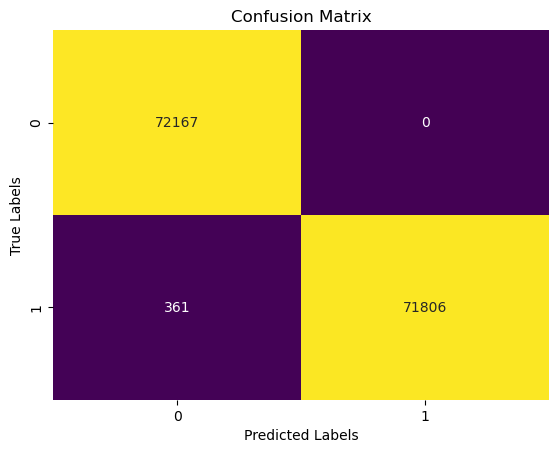

In [76]:
confMat = confusion_matrix(y_test,yPredictCatBoosting)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [77]:
print(format(classification_report(y_test,yPredictCatBoosting)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72167
           1       1.00      0.99      1.00     72167

    accuracy                           1.00    144334
   macro avg       1.00      1.00      1.00    144334
weighted avg       1.00      1.00      1.00    144334



In [80]:
print("f1 Score {}".format(f1_score(y_test,yPredictCatBoosting)))
print("Recall Score {}".format(recall_score(y_test,yPredictCatBoosting)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredictCatBoosting)))
print("Precision Score {}".format(precision_score(y_test,yPredictCatBoosting)))

f1 Score 0.9974925854153209
Recall Score 0.9949977136364266
Accuracy Score 0.9974988568182133
Precision Score 1.0


### LightGBM

In [81]:
ProcessLightGBM = LGBMClassifier()

In [83]:
ProcessLightGBM.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 288666, number of negative: 288666
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012637 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 894
[LightGBM] [Info] Number of data points in the train set: 577332, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

LGBMClassifier()

In [84]:
yPreditLightGBM = ProcessLightGBM.predict(x_test)

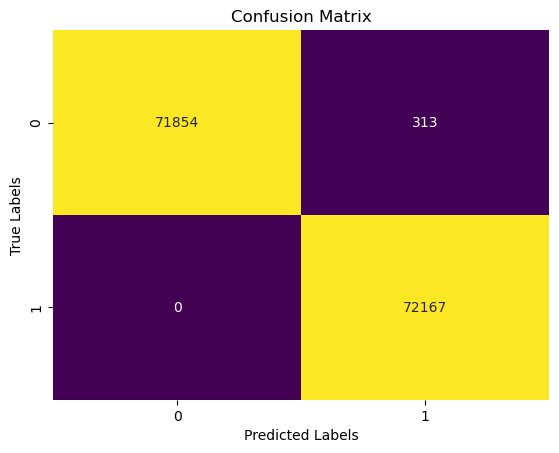

In [86]:
confMat = confusion_matrix(y_test,yPreditLightGBM)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [87]:
print(format(classification_report(y_test,yPreditLightGBM)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72167
           1       1.00      1.00      1.00     72167

    accuracy                           1.00    144334
   macro avg       1.00      1.00      1.00    144334
weighted avg       1.00      1.00      1.00    144334



In [90]:
print("f1 Score {}".format(f1_score(y_test,yPreditLightGBM)))
print("Recall Score {}".format(recall_score(y_test,yPreditLightGBM)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPreditLightGBM)))
print("Precision Score {}".format(precision_score(y_test,yPreditLightGBM)))

f1 Score 0.997836111360761
Recall Score 1.0
Accuracy Score 0.9978314187925229
Precision Score 0.9956815673289183


### AdaBoosting

In [92]:
ProcessAdaBoosting = AdaBoostClassifier()

In [94]:
ProcessAdaBoosting.fit(x_train,y_train)

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



AdaBoostClassifier()

In [96]:
yPredictAdaBoosting = ProcessAdaBoosting.predict(x_test)

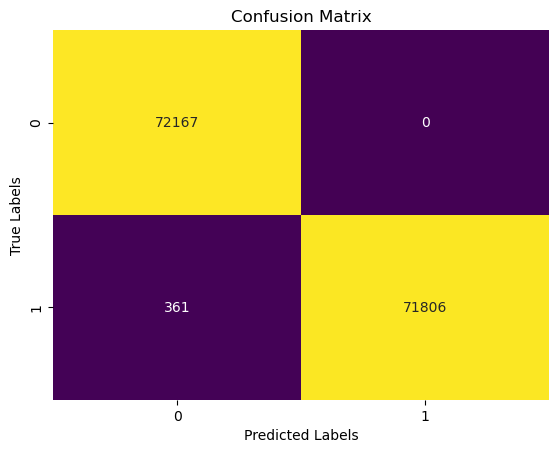

In [98]:
confMat = confusion_matrix(y_test,yPredictAdaBoosting)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [99]:
print(format(classification_report(y_test,yPredictAdaBoosting)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72167
           1       1.00      0.99      1.00     72167

    accuracy                           1.00    144334
   macro avg       1.00      1.00      1.00    144334
weighted avg       1.00      1.00      1.00    144334



In [100]:
print("f1 Score {}".format(f1_score(y_test,yPredictAdaBoosting)))
print("Recall Score {}".format(recall_score(y_test,yPredictAdaBoosting)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredictAdaBoosting)))
print("Precision Score {}".format(precision_score(y_test,yPredictAdaBoosting)))

f1 Score 0.9974925854153209
Recall Score 0.9949977136364266
Accuracy Score 0.9974988568182133
Precision Score 1.0


### XGBoost

In [101]:
ProcessXGBoost = XGBClassifier()

In [103]:
ProcessXGBoost.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [105]:
yPredictXGBoost = ProcessXGBoost.predict(x_test)

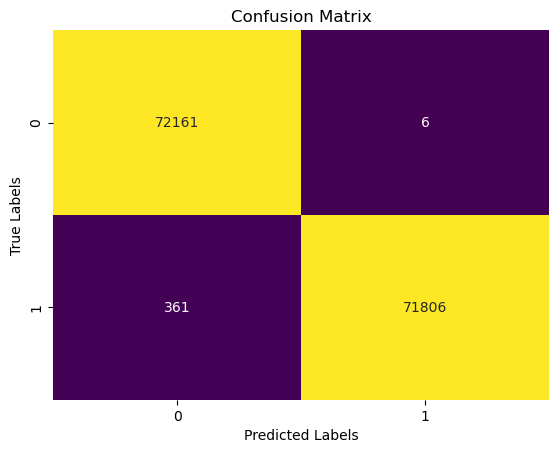

In [107]:
confMat = confusion_matrix(y_test,yPredictXGBoost)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(format(classification_report(y_test,yPredictXGBoost)))

In [109]:
print("f1 Score {}".format(f1_score(y_test,yPredictXGBoost)))
print("Recall Score {}".format(recall_score(y_test,yPredictXGBoost)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredictXGBoost)))
print("Precision Score {}".format(precision_score(y_test,yPredictXGBoost)))

f1 Score 0.9974510171622251
Recall Score 0.9949977136364266
Accuracy Score 0.9974572865714246
Precision Score 0.9999164485044282


### Logistic Regression

In [110]:
ProcessLogisticRegression = LogisticRegression()

In [111]:
ProcessLogisticRegression.fit(x_train,y_train)

LogisticRegression()

In [113]:
yPredLogisticRegression = ProcessLogisticRegression.predict(x_test)

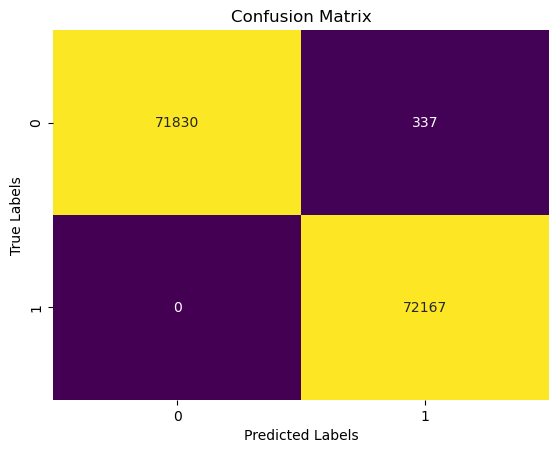

In [114]:
confMat = confusion_matrix(y_test,yPredLogisticRegression)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [115]:
print(format(classification_report(y_test,yPredLogisticRegression)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72167
           1       1.00      0.99      1.00     72167

    accuracy                           1.00    144334
   macro avg       1.00      1.00      1.00    144334
weighted avg       1.00      1.00      1.00    144334



In [116]:
print("f1 Score {}".format(f1_score(y_test,yPredLogisticRegression)))
print("Recall Score {}".format(recall_score(y_test,yPredLogisticRegression)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredLogisticRegression)))
print("Precision Score {}".format(precision_score(y_test,yPredLogisticRegression)))

f1 Score 0.997670576687795
Recall Score 1.0
Accuracy Score 0.9976651378053681
Precision Score 0.9953519805803818


### Decision Tree

In [118]:
ProcessDecisionTree = DecisionTreeClassifier()

In [119]:
ProcessDecisionTree.fit(x_train,y_train)

DecisionTreeClassifier()

In [123]:
yPredDecisionTree = ProcessDecisionTree.predict(x_test)

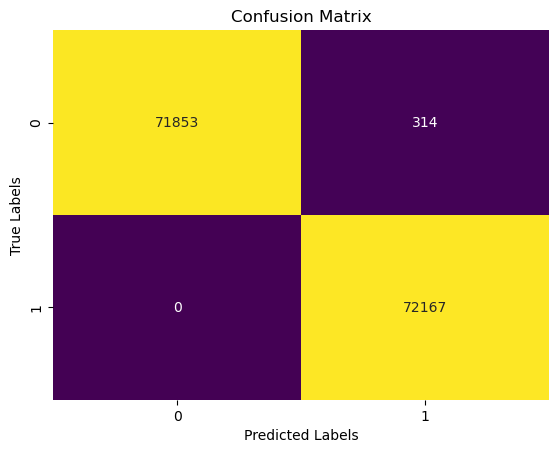

In [124]:
confMat = confusion_matrix(y_test,yPredDecisionTree)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [125]:
print(format(classification_report(y_test,yPredDecisionTree)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72167
           1       1.00      1.00      1.00     72167

    accuracy                           1.00    144334
   macro avg       1.00      1.00      1.00    144334
weighted avg       1.00      1.00      1.00    144334



In [127]:
print("f1 Score {}".format(f1_score(y_test,yPredDecisionTree)))
print("Recall Score {}".format(recall_score(y_test,yPredDecisionTree)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredDecisionTree)))
print("Precision Score {}".format(precision_score(y_test,yPredDecisionTree)))

f1 Score 0.9978292129860075
Recall Score 1.0
Accuracy Score 0.9978244904180581
Precision Score 0.9956678301899808


# Voting Clasifier

### Hard Voting

In [128]:
estimators = [("lr",ProcessLogisticRegression),("Gb",ProcessGradientBoosting),("Lg",ProcessLightGBM),("Cb",ProcessCatBoosting),("Dt",ProcessDecisionTree),("Rf",ProcessRandomForest)]

In [139]:
ProcessVotingClassifier = VotingClassifier(estimators=estimators,voting='hard')
result = cross_val_score(ProcessVotingClassifier,x,y,cv=10,scoring='accuracy')

[LightGBM] [Info] Number of positive: 324750, number of negative: 324749
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038873 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 649499, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500001 -> initscore=0.000003
[LightGBM] [Info] Start training from score 0.000003
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

30:	learn: 0.0000447	total: 7.23s	remaining: 3m 45s
31:	learn: 0.0000447	total: 7.31s	remaining: 3m 41s
32:	learn: 0.0000447	total: 7.4s	remaining: 3m 36s
33:	learn: 0.0000447	total: 7.48s	remaining: 3m 32s
34:	learn: 0.0000447	total: 7.56s	remaining: 3m 28s
35:	learn: 0.0000447	total: 7.64s	remaining: 3m 24s
36:	learn: 0.0000447	total: 7.72s	remaining: 3m 20s
37:	learn: 0.0000447	total: 7.79s	remaining: 3m 17s
38:	learn: 0.0000447	total: 7.86s	remaining: 3m 13s
39:	learn: 0.0000447	total: 7.93s	remaining: 3m 10s
40:	learn: 0.0000447	total: 8s	remaining: 3m 7s
41:	learn: 0.0000447	total: 8.08s	remaining: 3m 4s
42:	learn: 0.0000447	total: 8.16s	remaining: 3m 1s
43:	learn: 0.0000447	total: 8.24s	remaining: 2m 59s
44:	learn: 0.0000447	total: 8.33s	remaining: 2m 56s
45:	learn: 0.0000447	total: 8.41s	remaining: 2m 54s
46:	learn: 0.0000447	total: 8.49s	remaining: 2m 52s
47:	learn: 0.0000447	total: 8.58s	remaining: 2m 50s
48:	learn: 0.0000447	total: 8.66s	remaining: 2m 48s
49:	learn: 0.000044

189:	learn: 0.0000447	total: 26.9s	remaining: 1m 54s
190:	learn: 0.0000447	total: 27s	remaining: 1m 54s
191:	learn: 0.0000447	total: 27.1s	remaining: 1m 53s
192:	learn: 0.0000447	total: 27.2s	remaining: 1m 53s
193:	learn: 0.0000447	total: 27.2s	remaining: 1m 53s
194:	learn: 0.0000447	total: 27.3s	remaining: 1m 52s
195:	learn: 0.0000447	total: 27.4s	remaining: 1m 52s
196:	learn: 0.0000447	total: 27.5s	remaining: 1m 52s
197:	learn: 0.0000447	total: 27.6s	remaining: 1m 51s
198:	learn: 0.0000447	total: 27.7s	remaining: 1m 51s
199:	learn: 0.0000447	total: 27.7s	remaining: 1m 50s
200:	learn: 0.0000447	total: 27.8s	remaining: 1m 50s
201:	learn: 0.0000447	total: 27.9s	remaining: 1m 50s
202:	learn: 0.0000447	total: 28s	remaining: 1m 49s
203:	learn: 0.0000447	total: 28.1s	remaining: 1m 49s
204:	learn: 0.0000447	total: 28.2s	remaining: 1m 49s
205:	learn: 0.0000447	total: 28.3s	remaining: 1m 48s
206:	learn: 0.0000447	total: 28.3s	remaining: 1m 48s
207:	learn: 0.0000447	total: 28.4s	remaining: 1m 4

346:	learn: 0.0000447	total: 45.5s	remaining: 1m 25s
347:	learn: 0.0000447	total: 45.6s	remaining: 1m 25s
348:	learn: 0.0000447	total: 45.6s	remaining: 1m 25s
349:	learn: 0.0000447	total: 45.7s	remaining: 1m 24s
350:	learn: 0.0000447	total: 45.9s	remaining: 1m 24s
351:	learn: 0.0000447	total: 46s	remaining: 1m 24s
352:	learn: 0.0000447	total: 46.1s	remaining: 1m 24s
353:	learn: 0.0000447	total: 46.2s	remaining: 1m 24s
354:	learn: 0.0000447	total: 46.3s	remaining: 1m 24s
355:	learn: 0.0000447	total: 46.3s	remaining: 1m 23s
356:	learn: 0.0000447	total: 46.4s	remaining: 1m 23s
357:	learn: 0.0000447	total: 46.6s	remaining: 1m 23s
358:	learn: 0.0000447	total: 46.6s	remaining: 1m 23s
359:	learn: 0.0000447	total: 46.8s	remaining: 1m 23s
360:	learn: 0.0000447	total: 46.8s	remaining: 1m 22s
361:	learn: 0.0000447	total: 46.9s	remaining: 1m 22s
362:	learn: 0.0000447	total: 47s	remaining: 1m 22s
363:	learn: 0.0000447	total: 47.1s	remaining: 1m 22s
364:	learn: 0.0000447	total: 47.2s	remaining: 1m 2

504:	learn: 0.0000447	total: 1m	remaining: 59.2s
505:	learn: 0.0000447	total: 1m	remaining: 59.1s
506:	learn: 0.0000447	total: 1m	remaining: 58.9s
507:	learn: 0.0000447	total: 1m	remaining: 58.8s
508:	learn: 0.0000447	total: 1m	remaining: 58.6s
509:	learn: 0.0000447	total: 1m	remaining: 58.5s
510:	learn: 0.0000447	total: 1m 1s	remaining: 58.4s
511:	learn: 0.0000447	total: 1m 1s	remaining: 58.4s
512:	learn: 0.0000447	total: 1m 1s	remaining: 58.3s
513:	learn: 0.0000447	total: 1m 1s	remaining: 58.3s
514:	learn: 0.0000447	total: 1m 1s	remaining: 58.2s
515:	learn: 0.0000447	total: 1m 2s	remaining: 58.2s
516:	learn: 0.0000447	total: 1m 2s	remaining: 58.2s
517:	learn: 0.0000447	total: 1m 2s	remaining: 58.2s
518:	learn: 0.0000447	total: 1m 2s	remaining: 58.2s
519:	learn: 0.0000447	total: 1m 3s	remaining: 58.2s
520:	learn: 0.0000447	total: 1m 3s	remaining: 58.2s
521:	learn: 0.0000447	total: 1m 3s	remaining: 58.2s
522:	learn: 0.0000447	total: 1m 3s	remaining: 58.1s
523:	learn: 0.0000447	total: 1

...

273:	learn: 0.0035739	total: 34.5s	remaining: 1m 31s
274:	learn: 0.0035739	total: 34.6s	remaining: 1m 31s
275:	learn: 0.0035739	total: 34.8s	remaining: 1m 31s
276:	learn: 0.0035739	total: 35s	remaining: 1m 31s
277:	learn: 0.0035739	total: 35.2s	remaining: 1m 31s
278:	learn: 0.0035739	total: 35.5s	remaining: 1m 31s
279:	learn: 0.0035739	total: 35.6s	remaining: 1m 31s
280:	learn: 0.0035739	total: 35.8s	remaining: 1m 31s
281:	learn: 0.0035739	total: 36s	remaining: 1m 31s
282:	learn: 0.0035739	total: 36.2s	remaining: 1m 31s
283:	learn: 0.0035739	total: 36.4s	remaining: 1m 31s
284:	learn: 0.0035739	total: 36.5s	remaining: 1m 31s
285:	learn: 0.0035739	total: 36.6s	remaining: 1m 31s
286:	learn: 0.0035739	total: 36.6s	remaining: 1m 31s
287:	learn: 0.0035739	total: 36.7s	remaining: 1m 30s
288:	learn: 0.0035739	total: 36.8s	remaining: 1m 30s
289:	learn: 0.0035739	total: 36.9s	remaining: 1m 30s
290:	learn: 0.0035739	total: 37s	remaining: 1m 30s
291:	learn: 0.0035739	total: 37.1s	remaining: 1m 29s

429:	learn: 0.0035739	total: 53.4s	remaining: 1m 10s
430:	learn: 0.0035739	total: 53.6s	remaining: 1m 10s
431:	learn: 0.0035739	total: 53.8s	remaining: 1m 10s
432:	learn: 0.0035739	total: 54s	remaining: 1m 10s
433:	learn: 0.0035739	total: 54.2s	remaining: 1m 10s
434:	learn: 0.0035739	total: 54.4s	remaining: 1m 10s
435:	learn: 0.0035739	total: 54.7s	remaining: 1m 10s
436:	learn: 0.0035739	total: 54.9s	remaining: 1m 10s
437:	learn: 0.0035739	total: 55.1s	remaining: 1m 10s
438:	learn: 0.0035739	total: 55.3s	remaining: 1m 10s
439:	learn: 0.0035739	total: 55.6s	remaining: 1m 10s
440:	learn: 0.0035739	total: 55.7s	remaining: 1m 10s
441:	learn: 0.0035739	total: 55.9s	remaining: 1m 10s
442:	learn: 0.0035739	total: 56.2s	remaining: 1m 10s
443:	learn: 0.0035739	total: 56.4s	remaining: 1m 10s
444:	learn: 0.0035739	total: 56.6s	remaining: 1m 10s
445:	learn: 0.0035739	total: 56.7s	remaining: 1m 10s
446:	learn: 0.0035739	total: 56.8s	remaining: 1m 10s
447:	learn: 0.0035739	total: 56.8s	remaining: 1m

590:	learn: 0.0035739	total: 1m 11s	remaining: 49.7s
591:	learn: 0.0035739	total: 1m 11s	remaining: 49.6s
592:	learn: 0.0035739	total: 1m 12s	remaining: 49.5s
593:	learn: 0.0035739	total: 1m 12s	remaining: 49.4s
594:	learn: 0.0035739	total: 1m 12s	remaining: 49.3s
595:	learn: 0.0035739	total: 1m 12s	remaining: 49.2s
596:	learn: 0.0035739	total: 1m 12s	remaining: 49.2s
597:	learn: 0.0035739	total: 1m 13s	remaining: 49.1s
598:	learn: 0.0035739	total: 1m 13s	remaining: 49s
599:	learn: 0.0035739	total: 1m 13s	remaining: 48.9s
600:	learn: 0.0035739	total: 1m 13s	remaining: 48.9s
601:	learn: 0.0035739	total: 1m 13s	remaining: 48.8s
602:	learn: 0.0035739	total: 1m 13s	remaining: 48.7s
603:	learn: 0.0035739	total: 1m 14s	remaining: 48.7s
604:	learn: 0.0035739	total: 1m 14s	remaining: 48.6s
605:	learn: 0.0035739	total: 1m 14s	remaining: 48.5s
606:	learn: 0.0035739	total: 1m 14s	remaining: 48.5s
607:	learn: 0.0035739	total: 1m 15s	remaining: 48.4s
608:	learn: 0.0035739	total: 1m 15s	remaining: 4

748:	learn: 0.0035739	total: 1m 30s	remaining: 30.4s
749:	learn: 0.0035739	total: 1m 30s	remaining: 30.3s
750:	learn: 0.0035739	total: 1m 31s	remaining: 30.2s
751:	learn: 0.0035739	total: 1m 31s	remaining: 30s
752:	learn: 0.0035739	total: 1m 31s	remaining: 29.9s
753:	learn: 0.0035739	total: 1m 31s	remaining: 29.8s
754:	learn: 0.0035739	total: 1m 31s	remaining: 29.6s
755:	learn: 0.0035739	total: 1m 31s	remaining: 29.5s
756:	learn: 0.0035739	total: 1m 31s	remaining: 29.4s
757:	learn: 0.0035739	total: 1m 31s	remaining: 29.2s
758:	learn: 0.0035739	total: 1m 31s	remaining: 29.1s
759:	learn: 0.0035739	total: 1m 31s	remaining: 29s
760:	learn: 0.0035739	total: 1m 31s	remaining: 28.8s
761:	learn: 0.0035739	total: 1m 31s	remaining: 28.7s
762:	learn: 0.0035739	total: 1m 32s	remaining: 28.6s
763:	learn: 0.0035739	total: 1m 32s	remaining: 28.5s
764:	learn: 0.0035739	total: 1m 32s	remaining: 28.4s
765:	learn: 0.0035739	total: 1m 32s	remaining: 28.3s
766:	learn: 0.0035739	total: 1m 32s	remaining: 28.

904:	learn: 0.0035739	total: 1m 50s	remaining: 11.6s
905:	learn: 0.0035739	total: 1m 50s	remaining: 11.4s
906:	learn: 0.0035739	total: 1m 50s	remaining: 11.3s
907:	learn: 0.0035739	total: 1m 50s	remaining: 11.2s
908:	learn: 0.0035739	total: 1m 50s	remaining: 11.1s
909:	learn: 0.0035739	total: 1m 50s	remaining: 10.9s
910:	learn: 0.0035739	total: 1m 50s	remaining: 10.8s
911:	learn: 0.0035739	total: 1m 50s	remaining: 10.7s
912:	learn: 0.0035739	total: 1m 50s	remaining: 10.6s
913:	learn: 0.0035739	total: 1m 50s	remaining: 10.4s
914:	learn: 0.0035739	total: 1m 50s	remaining: 10.3s
915:	learn: 0.0035739	total: 1m 51s	remaining: 10.2s
916:	learn: 0.0035739	total: 1m 51s	remaining: 10.1s
917:	learn: 0.0035739	total: 1m 51s	remaining: 9.93s
918:	learn: 0.0035739	total: 1m 51s	remaining: 9.8s
919:	learn: 0.0035739	total: 1m 51s	remaining: 9.68s
920:	learn: 0.0035739	total: 1m 51s	remaining: 9.56s
921:	learn: 0.0035739	total: 1m 51s	remaining: 9.43s
922:	learn: 0.0035739	total: 1m 51s	remaining: 

In [140]:
print(np.mean(result)*100)

99.75847686615766


### Soft Voting

In [141]:
ProcessVotingClassifier = VotingClassifier(estimators=estimators,voting='soft')
result1 = cross_val_score(ProcessVotingClassifier,x,y,cv=10,scoring='accuracy')

[LightGBM] [Info] Number of positive: 324750, number of negative: 324749
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013344 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 649499, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500001 -> initscore=0.000003
[LightGBM] [Info] Start training from score 0.000003
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

30:	learn: 0.0000447	total: 2.39s	remaining: 1m 14s
31:	learn: 0.0000447	total: 2.46s	remaining: 1m 14s
32:	learn: 0.0000447	total: 2.52s	remaining: 1m 13s
33:	learn: 0.0000447	total: 2.58s	remaining: 1m 13s
34:	learn: 0.0000447	total: 2.65s	remaining: 1m 12s
35:	learn: 0.0000447	total: 2.71s	remaining: 1m 12s
36:	learn: 0.0000447	total: 2.78s	remaining: 1m 12s
37:	learn: 0.0000447	total: 2.85s	remaining: 1m 12s
38:	learn: 0.0000447	total: 2.92s	remaining: 1m 11s
39:	learn: 0.0000447	total: 2.99s	remaining: 1m 11s
40:	learn: 0.0000447	total: 3.05s	remaining: 1m 11s
41:	learn: 0.0000447	total: 3.12s	remaining: 1m 11s
42:	learn: 0.0000447	total: 3.19s	remaining: 1m 11s
43:	learn: 0.0000447	total: 3.26s	remaining: 1m 10s
44:	learn: 0.0000447	total: 3.33s	remaining: 1m 10s
45:	learn: 0.0000447	total: 3.4s	remaining: 1m 10s
46:	learn: 0.0000447	total: 3.46s	remaining: 1m 10s
47:	learn: 0.0000447	total: 3.53s	remaining: 1m 10s
48:	learn: 0.0000447	total: 3.59s	remaining: 1m 9s
49:	learn: 0.0

192:	learn: 0.0000447	total: 14.3s	remaining: 59.7s
193:	learn: 0.0000447	total: 14.4s	remaining: 59.6s
194:	learn: 0.0000447	total: 14.4s	remaining: 59.6s
195:	learn: 0.0000447	total: 14.5s	remaining: 59.5s
196:	learn: 0.0000447	total: 14.6s	remaining: 59.5s
197:	learn: 0.0000447	total: 14.7s	remaining: 59.4s
198:	learn: 0.0000447	total: 14.7s	remaining: 59.3s
199:	learn: 0.0000447	total: 14.8s	remaining: 59.3s
200:	learn: 0.0000447	total: 14.9s	remaining: 59.2s
201:	learn: 0.0000447	total: 15s	remaining: 59.1s
202:	learn: 0.0000447	total: 15s	remaining: 59s
203:	learn: 0.0000447	total: 15.1s	remaining: 58.9s
204:	learn: 0.0000447	total: 15.2s	remaining: 58.9s
205:	learn: 0.0000447	total: 15.3s	remaining: 58.9s
206:	learn: 0.0000447	total: 15.3s	remaining: 58.8s
207:	learn: 0.0000447	total: 15.4s	remaining: 58.8s
208:	learn: 0.0000447	total: 15.5s	remaining: 58.7s
209:	learn: 0.0000447	total: 15.6s	remaining: 58.6s
210:	learn: 0.0000447	total: 15.6s	remaining: 58.5s
211:	learn: 0.0000

351:	learn: 0.0000447	total: 25.8s	remaining: 47.4s
352:	learn: 0.0000447	total: 25.8s	remaining: 47.4s
353:	learn: 0.0000447	total: 25.9s	remaining: 47.3s
354:	learn: 0.0000447	total: 26s	remaining: 47.2s
355:	learn: 0.0000447	total: 26s	remaining: 47.1s
356:	learn: 0.0000447	total: 26.1s	remaining: 47s
357:	learn: 0.0000447	total: 26.2s	remaining: 47s
358:	learn: 0.0000447	total: 26.3s	remaining: 46.9s
359:	learn: 0.0000447	total: 26.3s	remaining: 46.8s
360:	learn: 0.0000447	total: 26.4s	remaining: 46.7s
361:	learn: 0.0000447	total: 26.5s	remaining: 46.7s
362:	learn: 0.0000447	total: 26.6s	remaining: 46.6s
363:	learn: 0.0000447	total: 26.7s	remaining: 46.6s
364:	learn: 0.0000447	total: 26.7s	remaining: 46.5s
365:	learn: 0.0000447	total: 26.8s	remaining: 46.4s
366:	learn: 0.0000447	total: 26.9s	remaining: 46.4s
367:	learn: 0.0000447	total: 27s	remaining: 46.3s
368:	learn: 0.0000447	total: 27s	remaining: 46.2s
369:	learn: 0.0000447	total: 27.1s	remaining: 46.2s
370:	learn: 0.0000447	to

510:	learn: 0.0000447	total: 37.4s	remaining: 35.8s
511:	learn: 0.0000447	total: 37.4s	remaining: 35.7s
512:	learn: 0.0000447	total: 37.5s	remaining: 35.6s
513:	learn: 0.0000447	total: 37.6s	remaining: 35.6s
514:	learn: 0.0000447	total: 37.7s	remaining: 35.5s
515:	learn: 0.0000447	total: 37.7s	remaining: 35.4s
516:	learn: 0.0000447	total: 37.8s	remaining: 35.3s
517:	learn: 0.0000447	total: 37.9s	remaining: 35.3s
518:	learn: 0.0000447	total: 38s	remaining: 35.2s
519:	learn: 0.0000447	total: 38s	remaining: 35.1s
520:	learn: 0.0000447	total: 38.1s	remaining: 35s
521:	learn: 0.0000447	total: 38.2s	remaining: 35s
522:	learn: 0.0000447	total: 38.3s	remaining: 34.9s
523:	learn: 0.0000447	total: 38.3s	remaining: 34.8s
524:	learn: 0.0000447	total: 38.4s	remaining: 34.8s
525:	learn: 0.0000447	total: 38.5s	remaining: 34.7s
526:	learn: 0.0000447	total: 38.5s	remaining: 34.6s
527:	learn: 0.0000447	total: 38.6s	remaining: 34.5s
528:	learn: 0.0000447	total: 38.7s	remaining: 34.5s
529:	learn: 0.000044

...

355:	learn: 0.0035739	total: 22.9s	remaining: 41.5s
356:	learn: 0.0035739	total: 23s	remaining: 41.4s
357:	learn: 0.0035739	total: 23.1s	remaining: 41.4s
358:	learn: 0.0035739	total: 23.1s	remaining: 41.3s
359:	learn: 0.0035739	total: 23.2s	remaining: 41.2s
360:	learn: 0.0035739	total: 23.2s	remaining: 41.2s
361:	learn: 0.0035739	total: 23.3s	remaining: 41.1s
362:	learn: 0.0035739	total: 23.4s	remaining: 41s
363:	learn: 0.0035739	total: 23.4s	remaining: 41s
364:	learn: 0.0035739	total: 23.5s	remaining: 40.9s
365:	learn: 0.0035739	total: 23.6s	remaining: 40.8s
366:	learn: 0.0035739	total: 23.6s	remaining: 40.8s
367:	learn: 0.0035739	total: 23.7s	remaining: 40.7s
368:	learn: 0.0035739	total: 23.8s	remaining: 40.6s
369:	learn: 0.0035739	total: 23.8s	remaining: 40.6s
370:	learn: 0.0035739	total: 23.9s	remaining: 40.5s
371:	learn: 0.0035739	total: 24s	remaining: 40.5s
372:	learn: 0.0035739	total: 24s	remaining: 40.4s
373:	learn: 0.0035739	total: 24.1s	remaining: 40.3s
374:	learn: 0.0035739	

515:	learn: 0.0035739	total: 33.1s	remaining: 31s
516:	learn: 0.0035739	total: 33.1s	remaining: 31s
517:	learn: 0.0035739	total: 33.2s	remaining: 30.9s
518:	learn: 0.0035739	total: 33.3s	remaining: 30.8s
519:	learn: 0.0035739	total: 33.3s	remaining: 30.8s
520:	learn: 0.0035739	total: 33.4s	remaining: 30.7s
521:	learn: 0.0035739	total: 33.4s	remaining: 30.6s
522:	learn: 0.0035739	total: 33.5s	remaining: 30.6s
523:	learn: 0.0035739	total: 33.6s	remaining: 30.5s
524:	learn: 0.0035739	total: 33.6s	remaining: 30.4s
525:	learn: 0.0035739	total: 33.7s	remaining: 30.4s
526:	learn: 0.0035739	total: 33.8s	remaining: 30.3s
527:	learn: 0.0035739	total: 33.8s	remaining: 30.2s
528:	learn: 0.0035739	total: 33.9s	remaining: 30.2s
529:	learn: 0.0035739	total: 34s	remaining: 30.1s
530:	learn: 0.0035739	total: 34s	remaining: 30s
531:	learn: 0.0035739	total: 34.1s	remaining: 30s
532:	learn: 0.0035739	total: 34.1s	remaining: 29.9s
533:	learn: 0.0035739	total: 34.2s	remaining: 29.9s
534:	learn: 0.0035739	to

674:	learn: 0.0035739	total: 43.2s	remaining: 20.8s
675:	learn: 0.0035739	total: 43.2s	remaining: 20.7s
676:	learn: 0.0035739	total: 43.3s	remaining: 20.6s
677:	learn: 0.0035739	total: 43.3s	remaining: 20.6s
678:	learn: 0.0035739	total: 43.4s	remaining: 20.5s
679:	learn: 0.0035739	total: 43.5s	remaining: 20.5s
680:	learn: 0.0035739	total: 43.5s	remaining: 20.4s
681:	learn: 0.0035739	total: 43.6s	remaining: 20.3s
682:	learn: 0.0035739	total: 43.7s	remaining: 20.3s
683:	learn: 0.0035739	total: 43.7s	remaining: 20.2s
684:	learn: 0.0035739	total: 43.8s	remaining: 20.1s
685:	learn: 0.0035739	total: 43.8s	remaining: 20.1s
686:	learn: 0.0035739	total: 43.9s	remaining: 20s
687:	learn: 0.0035739	total: 44s	remaining: 19.9s
688:	learn: 0.0035739	total: 44s	remaining: 19.9s
689:	learn: 0.0035739	total: 44.1s	remaining: 19.8s
690:	learn: 0.0035739	total: 44.2s	remaining: 19.7s
691:	learn: 0.0035739	total: 44.2s	remaining: 19.7s
692:	learn: 0.0035739	total: 44.3s	remaining: 19.6s
693:	learn: 0.0035

835:	learn: 0.0035739	total: 53.4s	remaining: 10.5s
836:	learn: 0.0035739	total: 53.5s	remaining: 10.4s
837:	learn: 0.0035739	total: 53.5s	remaining: 10.3s
838:	learn: 0.0035739	total: 53.6s	remaining: 10.3s
839:	learn: 0.0035739	total: 53.7s	remaining: 10.2s
840:	learn: 0.0035739	total: 53.7s	remaining: 10.2s
841:	learn: 0.0035739	total: 53.8s	remaining: 10.1s
842:	learn: 0.0035739	total: 53.9s	remaining: 10s
843:	learn: 0.0035739	total: 53.9s	remaining: 9.96s
844:	learn: 0.0035739	total: 54s	remaining: 9.9s
845:	learn: 0.0035739	total: 54s	remaining: 9.84s
846:	learn: 0.0035739	total: 54.1s	remaining: 9.77s
847:	learn: 0.0035739	total: 54.2s	remaining: 9.71s
848:	learn: 0.0035739	total: 54.2s	remaining: 9.64s
849:	learn: 0.0035739	total: 54.3s	remaining: 9.58s
850:	learn: 0.0035739	total: 54.4s	remaining: 9.52s
851:	learn: 0.0035739	total: 54.4s	remaining: 9.45s
852:	learn: 0.0035739	total: 54.5s	remaining: 9.39s
853:	learn: 0.0035739	total: 54.5s	remaining: 9.32s
854:	learn: 0.00357

997:	learn: 0.0035739	total: 1m 3s	remaining: 128ms
998:	learn: 0.0035739	total: 1m 3s	remaining: 64ms
999:	learn: 0.0035739	total: 1m 4s	remaining: 0us


In [143]:
print(np.mean(result1)*100)

99.7570911912647


### Stacking

In [144]:
StackEstimetors = [("Lr",ProcessLogisticRegression),("Dt",ProcessDecisionTree),("Rf",ProcessRandomForest),("Cb",ProcessCatBoosting),("Lgbm",ProcessLightGBM)]

In [147]:
ProcessStacking = StackingClassifier(estimators=StackEstimetors,final_estimator=ProcessGradientBoosting,cv=5)

In [148]:
ProcessStacking.fit(x_train,y_train)

Learning rate set to 0.155619
0:	learn: 0.2142465	total: 72.8ms	remaining: 1m 12s
1:	learn: 0.0634018	total: 146ms	remaining: 1m 12s
2:	learn: 0.0243585	total: 218ms	remaining: 1m 12s
3:	learn: 0.0118096	total: 284ms	remaining: 1m 10s
4:	learn: 0.0069712	total: 350ms	remaining: 1m 9s
5:	learn: 0.0048195	total: 424ms	remaining: 1m 10s
6:	learn: 0.0043233	total: 492ms	remaining: 1m 9s
7:	learn: 0.0037772	total: 562ms	remaining: 1m 9s
8:	learn: 0.0036181	total: 623ms	remaining: 1m 8s
9:	learn: 0.0035220	total: 682ms	remaining: 1m 7s
10:	learn: 0.0034006	total: 748ms	remaining: 1m 7s
11:	learn: 0.0033778	total: 801ms	remaining: 1m 5s
12:	learn: 0.0033648	total: 851ms	remaining: 1m 4s
13:	learn: 0.0033531	total: 910ms	remaining: 1m 4s
14:	learn: 0.0033506	total: 968ms	remaining: 1m 3s
15:	learn: 0.0033506	total: 1.01s	remaining: 1m 2s
16:	learn: 0.0033108	total: 1.07s	remaining: 1m 2s
17:	learn: 0.0032964	total: 1.14s	remaining: 1m 2s
18:	learn: 0.0032732	total: 1.2s	remaining: 1m 2s
19:	le

162:	learn: 0.0032518	total: 9.59s	remaining: 49.2s
163:	learn: 0.0032518	total: 9.64s	remaining: 49.2s
164:	learn: 0.0032518	total: 9.7s	remaining: 49.1s
165:	learn: 0.0032518	total: 9.76s	remaining: 49s
166:	learn: 0.0032518	total: 9.83s	remaining: 49.1s
167:	learn: 0.0032518	total: 9.89s	remaining: 49s
168:	learn: 0.0032518	total: 9.96s	remaining: 49s
169:	learn: 0.0032518	total: 10s	remaining: 49s
170:	learn: 0.0032518	total: 10.1s	remaining: 49s
171:	learn: 0.0032518	total: 10.2s	remaining: 48.9s
172:	learn: 0.0032518	total: 10.2s	remaining: 48.9s
173:	learn: 0.0032518	total: 10.3s	remaining: 48.8s
174:	learn: 0.0032518	total: 10.3s	remaining: 48.7s
175:	learn: 0.0032518	total: 10.4s	remaining: 48.6s
176:	learn: 0.0032518	total: 10.4s	remaining: 48.6s
177:	learn: 0.0032518	total: 10.5s	remaining: 48.5s
178:	learn: 0.0032518	total: 10.6s	remaining: 48.4s
179:	learn: 0.0032518	total: 10.6s	remaining: 48.4s
180:	learn: 0.0032518	total: 10.7s	remaining: 48.3s
181:	learn: 0.0032518	tot

322:	learn: 0.0032518	total: 20.1s	remaining: 42.1s
323:	learn: 0.0032518	total: 20.1s	remaining: 42s
324:	learn: 0.0032518	total: 20.2s	remaining: 42s
325:	learn: 0.0032518	total: 20.3s	remaining: 41.9s
326:	learn: 0.0032518	total: 20.3s	remaining: 41.8s
327:	learn: 0.0032518	total: 20.4s	remaining: 41.8s
328:	learn: 0.0032518	total: 20.5s	remaining: 41.7s
329:	learn: 0.0032518	total: 20.5s	remaining: 41.7s
330:	learn: 0.0032518	total: 20.6s	remaining: 41.6s
331:	learn: 0.0032518	total: 20.6s	remaining: 41.5s
332:	learn: 0.0032518	total: 20.7s	remaining: 41.5s
333:	learn: 0.0032518	total: 20.8s	remaining: 41.4s
334:	learn: 0.0032518	total: 20.8s	remaining: 41.4s
335:	learn: 0.0032518	total: 20.9s	remaining: 41.3s
336:	learn: 0.0032518	total: 21s	remaining: 41.2s
337:	learn: 0.0032518	total: 21s	remaining: 41.2s
338:	learn: 0.0032518	total: 21.1s	remaining: 41.1s
339:	learn: 0.0032518	total: 21.2s	remaining: 41.1s
340:	learn: 0.0032518	total: 21.2s	remaining: 41s
341:	learn: 0.0032518	

484:	learn: 0.0032518	total: 30.8s	remaining: 32.7s
485:	learn: 0.0032518	total: 30.9s	remaining: 32.6s
486:	learn: 0.0032518	total: 30.9s	remaining: 32.6s
487:	learn: 0.0032518	total: 31s	remaining: 32.5s
488:	learn: 0.0032518	total: 31.1s	remaining: 32.5s
489:	learn: 0.0032518	total: 31.1s	remaining: 32.4s
490:	learn: 0.0032518	total: 31.2s	remaining: 32.3s
491:	learn: 0.0032518	total: 31.2s	remaining: 32.3s
492:	learn: 0.0032518	total: 31.3s	remaining: 32.2s
493:	learn: 0.0032518	total: 31.4s	remaining: 32.1s
494:	learn: 0.0032518	total: 31.4s	remaining: 32.1s
495:	learn: 0.0032518	total: 31.5s	remaining: 32s
496:	learn: 0.0032518	total: 31.6s	remaining: 31.9s
497:	learn: 0.0032518	total: 31.6s	remaining: 31.9s
498:	learn: 0.0032518	total: 31.7s	remaining: 31.8s
499:	learn: 0.0032518	total: 31.7s	remaining: 31.7s
500:	learn: 0.0032518	total: 31.8s	remaining: 31.7s
501:	learn: 0.0032518	total: 31.9s	remaining: 31.6s
502:	learn: 0.0032518	total: 31.9s	remaining: 31.5s
503:	learn: 0.00

644:	learn: 0.0032518	total: 40.9s	remaining: 22.5s
645:	learn: 0.0032518	total: 41s	remaining: 22.5s
646:	learn: 0.0032518	total: 41.1s	remaining: 22.4s
647:	learn: 0.0032518	total: 41.1s	remaining: 22.3s
648:	learn: 0.0032518	total: 41.2s	remaining: 22.3s
649:	learn: 0.0032518	total: 41.3s	remaining: 22.2s
650:	learn: 0.0032518	total: 41.3s	remaining: 22.1s
651:	learn: 0.0032518	total: 41.4s	remaining: 22.1s
652:	learn: 0.0032518	total: 41.4s	remaining: 22s
653:	learn: 0.0032518	total: 41.5s	remaining: 22s
654:	learn: 0.0032518	total: 41.6s	remaining: 21.9s
655:	learn: 0.0032518	total: 41.6s	remaining: 21.8s
656:	learn: 0.0032518	total: 41.7s	remaining: 21.8s
657:	learn: 0.0032518	total: 41.8s	remaining: 21.7s
658:	learn: 0.0032518	total: 41.8s	remaining: 21.6s
659:	learn: 0.0032518	total: 41.9s	remaining: 21.6s
660:	learn: 0.0032518	total: 41.9s	remaining: 21.5s
661:	learn: 0.0032518	total: 42s	remaining: 21.4s
662:	learn: 0.0032518	total: 42.1s	remaining: 21.4s
663:	learn: 0.003251

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

StackingClassifier(cv=5,
                   estimators=[('Lr', LogisticRegression()),
                               ('Dt', DecisionTreeClassifier()),
                               ('Rf', RandomForestClassifier()),
                               ('Cb',
                                <catboost.core.CatBoostClassifier object at 0x0000022AA9A44850>),
                               ('Lgbm', LGBMClassifier())],
                   final_estimator=GradientBoostingClassifier())

In [149]:
yPredStacking = ProcessStacking.predict(x_test)

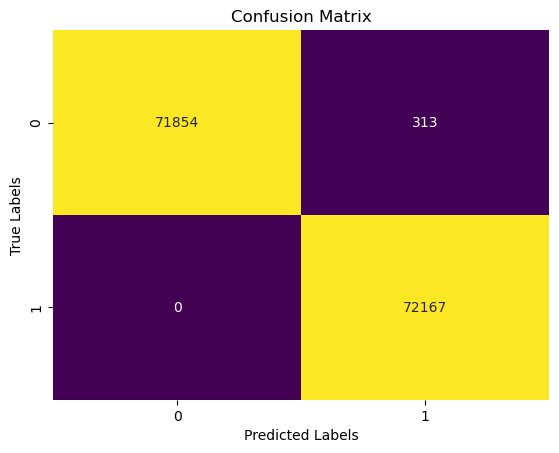

In [150]:
confMat = confusion_matrix(y_test,yPredStacking)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [151]:
print(format(classification_report(y_test,yPredStacking)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72167
           1       1.00      1.00      1.00     72167

    accuracy                           1.00    144334
   macro avg       1.00      1.00      1.00    144334
weighted avg       1.00      1.00      1.00    144334



In [152]:
print("f1 Score {}".format(f1_score(y_test,yPredStacking)))
print("Recall Score {}".format(recall_score(y_test,yPredStacking)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredStacking)))
print("Precision Score {}".format(precision_score(y_test,yPredStacking)))

f1 Score 0.997836111360761
Recall Score 1.0
Accuracy Score 0.9978314187925229
Precision Score 0.9956815673289183
